In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
import pandas as pd

df = pd.read_csv(r"C:\Users\venka\Downloads\Personalized_Precision_Oncology_Cleaned_Dataset.csv")

print(df.head())

  Encounter_Date     Cancer_Type  Cancer_Stage  Age     Sex Patient_Group  \
0     2024-01-08   Breast Cancer             2   54    Male       Group_C   
1     2023-11-23  Ovarian Cancer             4   60    Male       Group_B   
2     2024-11-20           NSCLC             2   69    Male       Group_D   
3     2025-04-03           NSCLC             4   57  Female       Group_D   
4     2022-08-02  Ovarian Cancer             4   63    Male       Group_B   

  Gene_Mutation  EGFR_Expression  KRAS_Expression  ALK_Expression  ...  \
0          KRAS            1.196            1.420           1.018  ...   
1          EGFR            2.928            3.082           5.432  ...   
2       Unknown            7.567            2.758           5.638  ...   
3          TP53            6.300            6.513           4.564  ...   
4          TP53            0.922            3.139           5.997  ...   

   Treatment_Drug  Dosage_mg  Treatment_Adherence_Pct  Prior_Therapies  \
0     Carboplatin 

In [15]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3893
Columns: 35


In [16]:
print(df.columns)
print(df.dtypes)

Index(['Encounter_Date', 'Cancer_Type', 'Cancer_Stage', 'Age', 'Sex',
       'Patient_Group', 'Gene_Mutation', 'EGFR_Expression', 'KRAS_Expression',
       'ALK_Expression', 'ctDNA_Level', 'Tumor_Marker', 'WBC_Count',
       'Hemoglobin', 'Platelet_Count', 'Creatinine', 'Bilirubin', 'ALT', 'AST',
       'Heart_Rate', 'Systolic_BP', 'Oxygen_Saturation', 'Temperature',
       'Symptom_Report', 'Comorbidities', 'Treatment_Drug', 'Dosage_mg',
       'Treatment_Adherence_Pct', 'Prior_Therapies', 'Treatment_Response',
       'Toxicity_Score', 'Toxicity_Risk', 'Risk_Score', 'Clinical_Note',
       'Symptom_Count'],
      dtype='object')
Encounter_Date              object
Cancer_Type                 object
Cancer_Stage                 int64
Age                          int64
Sex                         object
Patient_Group               object
Gene_Mutation               object
EGFR_Expression            float64
KRAS_Expression            float64
ALK_Expression             float64
ctDNA_Level 

In [17]:
print(df.isnull().sum())
print("Total Missing Values:", df.isnull().sum().sum())


Encounter_Date             0
Cancer_Type                0
Cancer_Stage               0
Age                        0
Sex                        0
Patient_Group              0
Gene_Mutation              0
EGFR_Expression            0
KRAS_Expression            0
ALK_Expression             0
ctDNA_Level                0
Tumor_Marker               0
WBC_Count                  0
Hemoglobin                 0
Platelet_Count             0
Creatinine                 0
Bilirubin                  0
ALT                        0
AST                        0
Heart_Rate                 0
Systolic_BP                0
Oxygen_Saturation          0
Temperature                0
Symptom_Report             0
Comorbidities              0
Treatment_Drug             0
Dosage_mg                  0
Treatment_Adherence_Pct    0
Prior_Therapies            0
Treatment_Response         0
Toxicity_Score             0
Toxicity_Risk              0
Risk_Score                 0
Clinical_Note              0
Symptom_Count 

In [18]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [19]:
print(df.describe())

       Cancer_Stage          Age  EGFR_Expression  KRAS_Expression  \
count   3893.000000  3893.000000      3893.000000      3893.000000   
mean       2.850501    57.758798         4.069858         3.564624   
std        0.981194    12.023129         2.270021         1.985421   
min        1.000000     0.000000         0.103000         0.101000   
25%        2.000000    50.000000         2.112000         1.877000   
50%        3.000000    58.000000         4.094000         3.572000   
75%        4.000000    66.000000         6.022000         5.258000   
max        4.000000    88.000000         7.999000         6.998000   

       ALK_Expression  ctDNA_Level  Tumor_Marker    WBC_Count   Hemoglobin  \
count     3893.000000  3893.000000   3893.000000  3893.000000  3893.000000   
mean         3.064808     3.691929     42.843610     7.168754    12.478176   
std          1.710608     3.321219     26.034451     2.003604     1.771636   
min          0.101000     0.166000      0.100000     2.00

In [20]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 Encounter_Date
Encounter_Date
2023-11-10    10
2023-05-21    10
2022-07-02    10
2023-01-02     9
2024-01-08     9
              ..
2023-10-16     1
2022-06-08     1
2022-09-23     1
2023-03-29     1
2022-04-07     1
Name: count, Length: 1154, dtype: int64

 Cancer_Type
Cancer_Type
Breast Cancer        820
Melanoma             799
NSCLC                770
Colorectal Cancer    767
Ovarian Cancer       737
Name: count, dtype: int64

 Sex
Sex
Female    1968
Male      1925
Name: count, dtype: int64

 Patient_Group
Patient_Group
Group_D    829
Unknown    799
Group_C    766
Group_A    766
Group_B    733
Name: count, dtype: int64

 Gene_Mutation
Gene_Mutation
TP53       718
Unknown    598
EGFR       581
KRAS       442
BRAF       315
ALK        300
PIK3CA     276
MET        262
ROS1       201
RET        200
Name: count, dtype: int64

 Symptom_Report
Symptom_Report
fatigue                436
neuropathy             388
none                   379
pain                   379
appetite loss        

In [21]:
numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(column, ":", len(outliers), "outliers")

Cancer_Stage : 0 outliers
Age : 12 outliers
EGFR_Expression : 0 outliers
KRAS_Expression : 0 outliers
ALK_Expression : 0 outliers
ctDNA_Level : 283 outliers
Tumor_Marker : 18 outliers
WBC_Count : 10 outliers
Hemoglobin : 35 outliers
Platelet_Count : 8 outliers
Creatinine : 20 outliers
Bilirubin : 10 outliers
ALT : 9 outliers
AST : 15 outliers
Heart_Rate : 12 outliers
Systolic_BP : 10 outliers
Oxygen_Saturation : 14 outliers
Temperature : 25 outliers
Dosage_mg : 2 outliers
Treatment_Adherence_Pct : 11 outliers
Prior_Therapies : 15 outliers
Toxicity_Score : 12 outliers
Risk_Score : 16 outliers
Symptom_Count : 495 outliers


In [22]:
import os

os.makedirs("graphs", exist_ok=True)


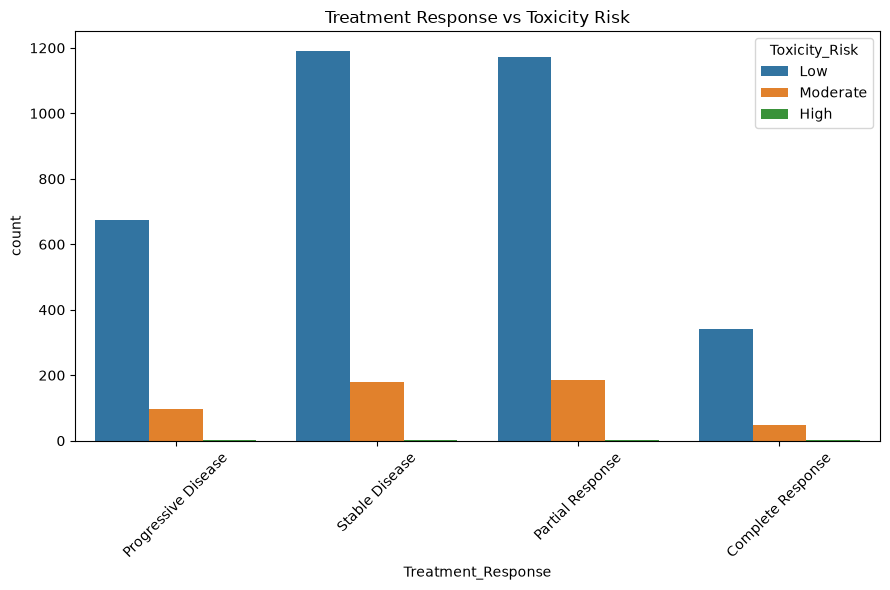

In [23]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="Treatment_Response",
    hue="Toxicity_Risk"
)

plt.title("Treatment Response vs Toxicity Risk")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "graphs/01_Treatment_Response_vs_Toxicity_Risk.png",
    dpi=300
)

plt.show()
plt.close()

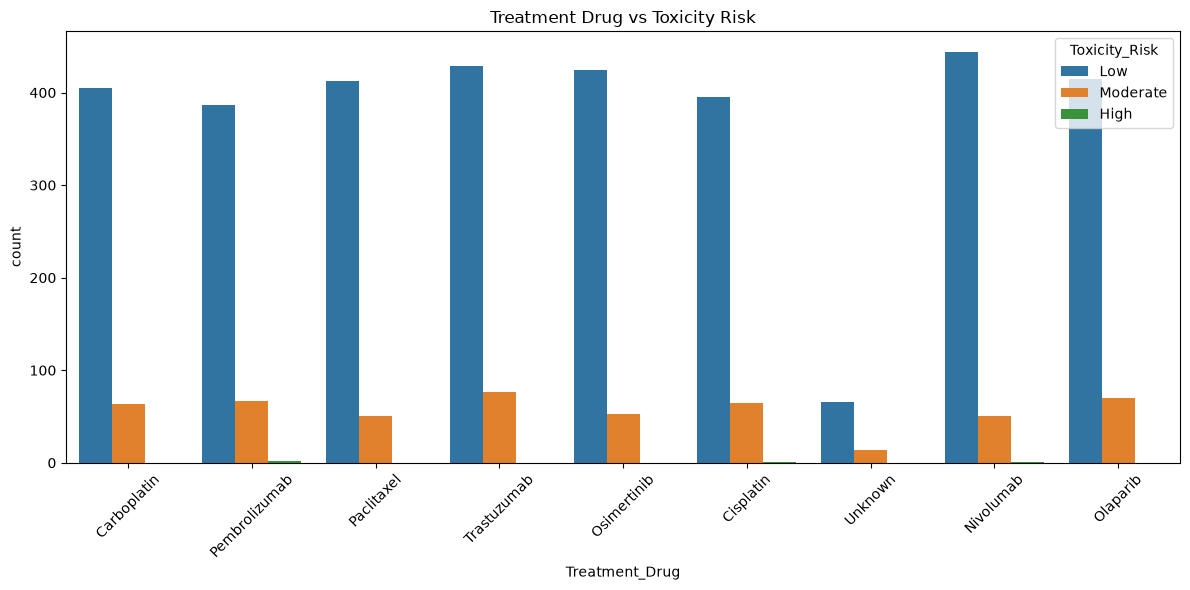

In [24]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Treatment_Drug",
    hue="Toxicity_Risk"
)

plt.title("Treatment Drug vs Toxicity Risk")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "graphs/02_Treatment_Drug_vs_Toxicity_Risk.png",
    dpi=300
)

plt.show()
plt.close()

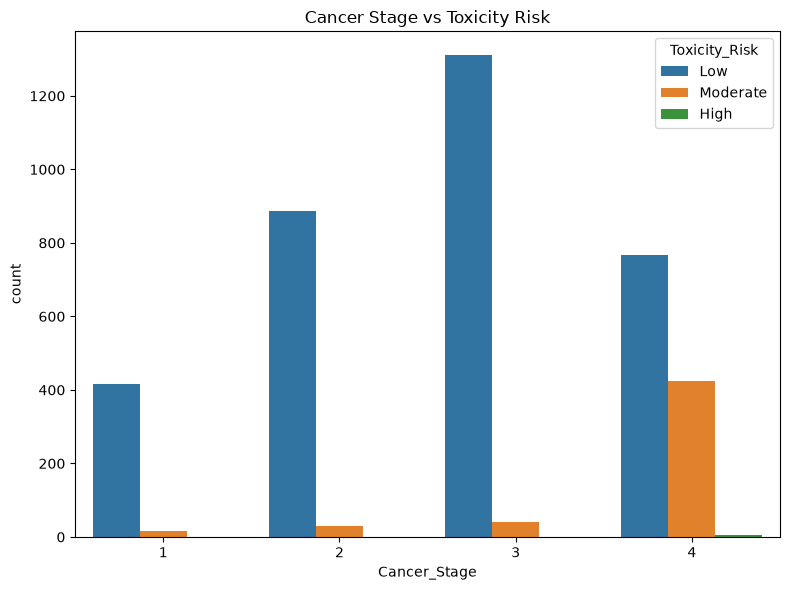

In [25]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="Cancer_Stage",
    hue="Toxicity_Risk"
)

plt.title("Cancer Stage vs Toxicity Risk")
plt.tight_layout()

plt.savefig(
    "graphs/03_Cancer_Stage_vs_Toxicity_Risk.png",
    dpi=300
)

plt.show()
plt.close()

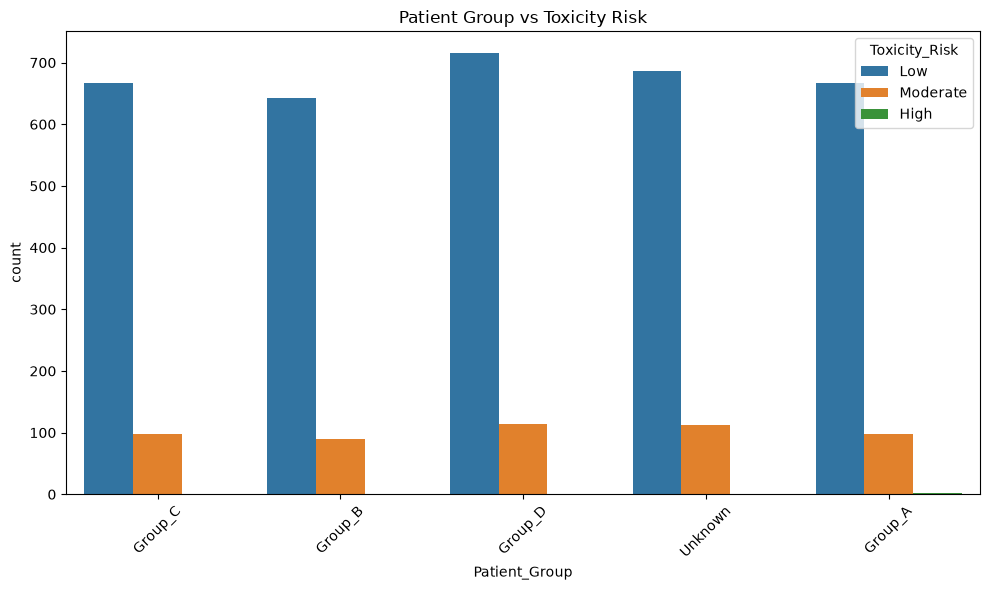

In [26]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Patient_Group",
    hue="Toxicity_Risk"
)

plt.title("Patient Group vs Toxicity Risk")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "graphs/04_Patient_Group_vs_Toxicity_Risk.png",
    dpi=300
)

plt.show()
plt.close()

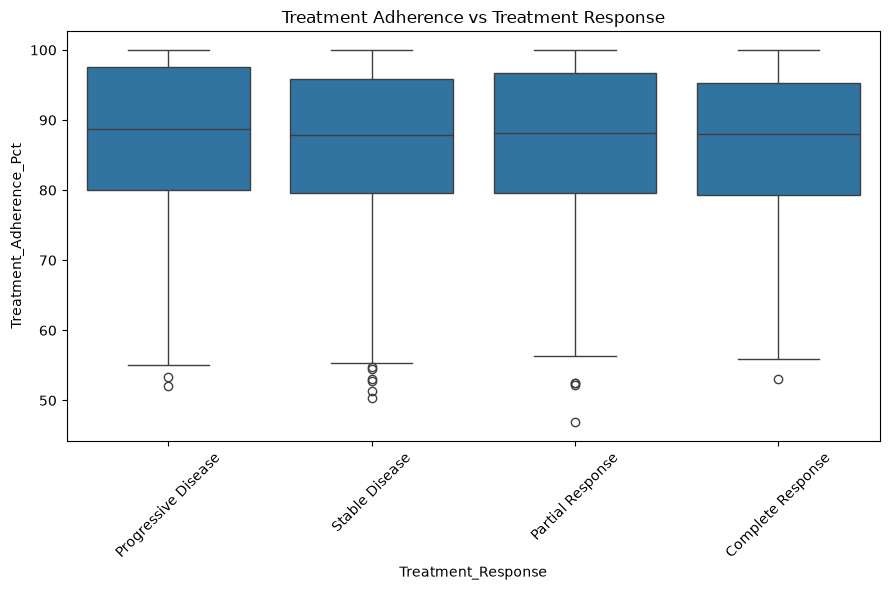

In [27]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Treatment_Response",
    y="Treatment_Adherence_Pct"
)

plt.title("Treatment Adherence vs Treatment Response")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "graphs/05_Treatment_Adherence_vs_Response.png",
    dpi=300
)

plt.show()
plt.close()

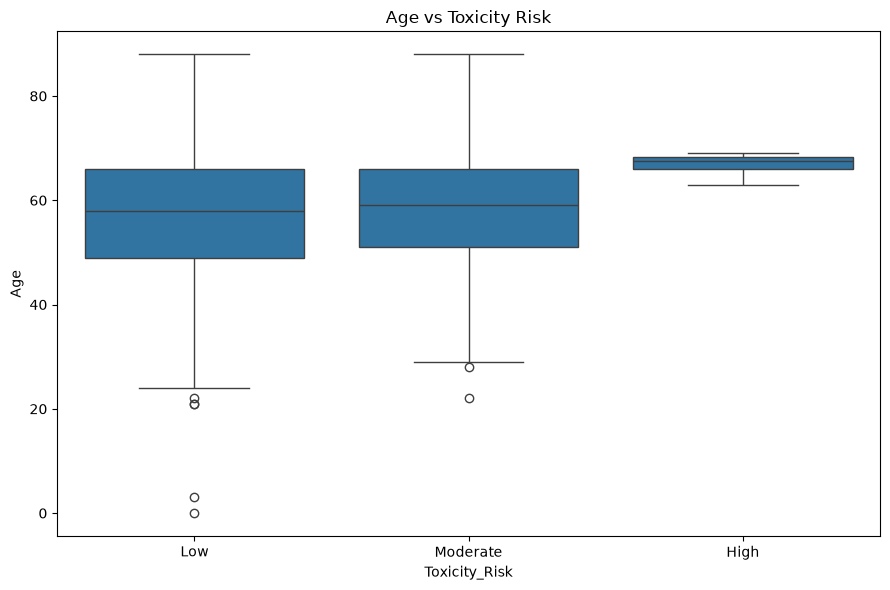

In [28]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Toxicity_Risk",
    y="Age"
)

plt.title("Age vs Toxicity Risk")
plt.tight_layout()

plt.savefig(
    "graphs/06_Age_vs_Toxicity_Risk.png",
    dpi=300
)

plt.show()
plt.close()

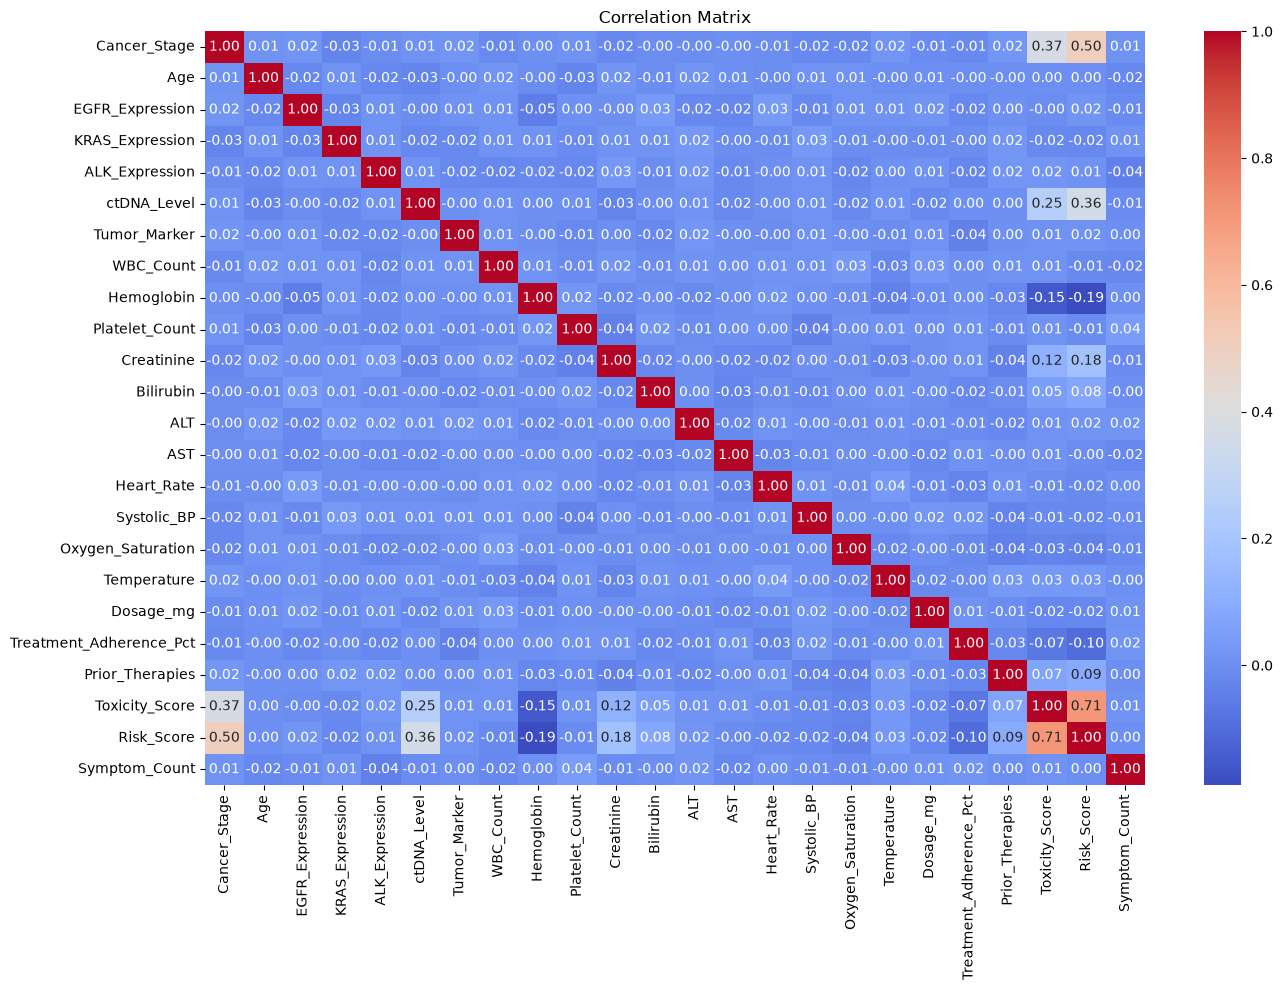

In [29]:
numerical_columns = df.select_dtypes(include=np.number).columns

correlation = df[numerical_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "graphs/07_Correlation_Matrix.png",
    dpi=300
)

plt.show()
plt.close()